# 🤖 IT Helpdesk AI Assistant — Domain-Specific LLM Fine-Tuning
### Built with Unsloth | Qwen2.5-1.5B | LoRA/QLoRA | DPO Alignment
---
## Stage 3: DPO Preference Alignment
---
**Dataset:** [Tobi-Bueck/customer-support-tickets](https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets) (HuggingFace) — 61.8k IT support tickets  
**Base Model:** Continuing from Stage 2 SFT adapter (kumarrohit1707/it-helpdesk-sft-adapter)  
**This Notebook Covers:**
1. Building (prompt, chosen, rejected) preference triples from ticket data
2. Saving as `dpo_dataset.jsonl` → pushing to HF Hub
3. Loading the SFT adapter as the starting point for alignment
4. Applying LoRA and running DPO training
5. Saving the DPO adapter and testing inference
6. Comparing Base vs SFT vs DPO outputs

**Hardware:** NVIDIA T4 (Google Colab / Kaggle Free GPU)

---
> **Business Problem:** Build an internal IT support assistant that understands domain-specific  
> terminology, triages tickets accurately, and gives precise resolutions — outperforming a  
> generic base model on real helpdesk queries.
>
> **Goal of this stage:** Align the model's preferences toward accurate, on-topic, professional  
> support responses and away from irrelevant, mismatched, or hallucinated ones — refining the  
> behavior learned during Stage 2 (SFT) rather than teaching new patterns from scratch.

## Install the required libraries

In [3]:
!pip install unsloth trl datasets huggingface_hub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 MB 26.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 91.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.2 MB/s eta 0:00:00:00:01
 

In [26]:
import os
import re
import torch
import warnings
import pandas as pd
from typing import List
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from huggingface_hub import login, HfApi
from datasets import Dataset, load_dataset
from dataclasses import dataclass, field
from trl import SFTTrainer, SFTConfig, DPOTrainer, DPOConfig
from unsloth.chat_templates import get_chat_template
from unsloth import FastLanguageModel, is_bfloat16_supported, UnslothTrainer, UnslothTrainingArguments
warnings.filterwarnings("ignore")

In [5]:
os.makedirs("data",exist_ok=True)

In [6]:
import transformers
transformers.logging.set_verbosity_error()

In [34]:
from typing import List
@dataclass
class DPOConfigParams:
    huggingface_dataset = "Tobi-Bueck/customer-support-tickets"
    model_name: str = "kumarrohit1707/it-helpdesk-sft-adapter"
    max_seq_length: int = 2048
    dtype: str = None
    load_in_4bit: bool = True
    lora_r: int = 16
    lora_alpha: int = 16
    lora_dropout: float = 0.0
    target_modules: List[str] = field(default_factory=lambda: [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ])
    bias: str = "none"
    use_gradient_checkpointing: str = "unsloth"
    random_state: int = 42
    per_device_train_batch_size: int = 1
    gradient_accumulation_steps: int = 4
    warmup_ratio: float = 0.1
    num_train_epochs: int = 3
    learning_rate: float = 5e-6
    beta: float = 0.1
    logging_steps: int = 5
    optim: str = "adamw_8bit"
    output_dir: str = "outputs/dpo"

cfg = DPOConfigParams()

In [8]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("HF_TOKEN")

In [9]:
 # log in huggingface hub
login(token=token)

In [10]:
dataset = load_dataset(cfg.huggingface_dataset)
print(dataset)

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [11]:
df = dataset['train'].to_pandas()

In [12]:
# only select those rows where the language is en (English)
df = df[df['language'] == 'en']

In [13]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br>", " ")
    text = text.replace("<name>", "the user")
    text = text.replace("<tel_num>", "a phone number")
    text = text.replace("<acc_num>", "an account number")
    text = text.replace("<email>", "an email address")
    text = text.replace("<website_url>", "a website link")
    text = text.replace("<user>", "the user")
    text = text.replace("\\n", " ").replace("\n", " ")
    text = " ".join(text.split())
    return text.strip()

In [14]:
it_queues = ["Technical Support", "IT Support", "Product Support", "Service Outages and Maintenance", "Billing and Payments"]
dpo_source = df[df["queue"].isin(it_queues)].copy()

dpo_source = dpo_source[["subject", "body", "answer"]].dropna().reset_index(drop=True)
dpo_source["body"] = dpo_source["body"].apply(clean_text)
dpo_source["answer"] = dpo_source["answer"].apply(clean_text)
dpo_source = dpo_source[dpo_source["body"].str.len() > 100]
dpo_source = dpo_source[dpo_source["answer"].str.len() > 100]
dpo_source = dpo_source.drop_duplicates(subset=["body", "answer"]).reset_index(drop=True)

print(f"Clean, in-domain source pool: {dpo_source.shape[0]}")

dpo_prompts_df = dpo_source.sample(n=150, random_state=42).reset_index(drop=True)
dpo_prompts_df["prompt"] = dpo_prompts_df.apply(lambda r: f"{r['subject']}. {r['body']}", axis=1)
prompts = dpo_prompts_df["prompt"].tolist()
print(f"Total prompts: {len(prompts)}")

Clean, in-domain source pool: 13370
Total prompts: 150


In [15]:
sft_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name="kumarrohit1707/it-helpdesk-sft-adapter",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

sft_tokenizer = get_chat_template(
    sft_tokenizer,
    chat_template="chatml",
)

FastLanguageModel.for_inference(sft_model)

im_end_id = sft_tokenizer.convert_tokens_to_ids("<|im_end|>")
sft_model.generation_config.eos_token_id = im_end_id
sft_model.generation_config.pad_token_id = sft_tokenizer.pad_token_id

def generate_sft(question, max_new_tokens=150):
    messages = [
        {"role": "system", "content": "You are an IT Helpdesk Assistant. Answer user IT support questions clearly and professionally."},
        {"role": "user", "content": question},
    ]
    inputs = sft_tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
    outputs = sft_model.generate(inputs, max_new_tokens=max_new_tokens, temperature=0.2, do_sample=True, repetition_penalty=1.2)
    return sft_tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

chosen_answers = []
for i, p in enumerate(prompts):
    ans = generate_sft(p)
    chosen_answers.append(ans)
    if i % 10 == 0:
        print(f"[{i}/150] done")

print("SFT generation complete")

==((====))==  Unsloth 2026.7.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[unsloth.chat_templates|WARNING]Unsloth: Will map <|im_end|> to EOS = <|endoftext|>.


[0/100] done
[10/100] done
[20/100] done
[30/100] done
[40/100] done
[50/100] done
[60/100] done
[70/100] done
[80/100] done
[90/100] done
[100/100] done
[110/100] done
[120/100] done
[130/100] done
[140/100] done
SFT generation complete


In [16]:
import gc, torch

del sft_model
gc.collect()
torch.cuda.empty_cache()

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(base_model)

def generate_base(question, max_new_tokens=200):
    inputs = base_tokenizer(question, return_tensors="pt").to("cuda")
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        do_sample=True,
        repetition_penalty=1.2,
        pad_token_id=base_tokenizer.eos_token_id,
    )
    return base_tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

rejected_answers = []
for i, p in enumerate(prompts):
    ans = generate_base(p)
    rejected_answers.append(ans)
    if i % 10 == 0:
        print(f"[{i}/150] done")

print("Base generation complete")

==((====))==  Unsloth 2026.7.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[0/100] done
[10/100] done
[20/100] done
[30/100] done
[40/100] done
[50/100] done
[60/100] done
[70/100] done
[80/100] done
[90/100] done
[100/100] done
[110/100] done
[120/100] done
[130/100] done
[140/100] done
Base generation complete


In [17]:
final_dpo_df = pd.DataFrame({
    "prompt": prompts,
    "chosen": chosen_answers,
    "rejected": rejected_answers,
})

# Clean newlines for safety
final_dpo_df["chosen"] = final_dpo_df["chosen"].apply(lambda x: " ".join(str(x).split()))
final_dpo_df["rejected"] = final_dpo_df["rejected"].apply(lambda x: " ".join(str(x).split()))

# Drop rows where generation failed/empty or chosen==rejected
final_dpo_df = final_dpo_df[final_dpo_df["chosen"].str.len() > 20]
final_dpo_df = final_dpo_df[final_dpo_df["rejected"].str.len() > 5]
final_dpo_df = final_dpo_df[final_dpo_df["chosen"] != final_dpo_df["rejected"]].reset_index(drop=True)

print(f"Final DPO dataset: {final_dpo_df.shape[0]} pairs")

import os
os.makedirs("data", exist_ok=True)
final_dpo_df.to_json("data/preference_dataset.jsonl", orient="records", lines=True, force_ascii=False)

from datasets import Dataset
dpo_dataset = Dataset.from_pandas(final_dpo_df)
dpo_dataset.push_to_hub("kumarrohit1707/it-helpdesk-dpo-data")

print("Saved and pushed")

Final DPO dataset: 139 pairs


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/342 [00:00<?, ?B/s]

Saved and pushed


In [19]:
def is_low_quality(text, min_len=20, max_len=800):
    if len(text) < min_len or len(text) > max_len:
        return True
    if text.count("/") > 8:
        return True
    words = text.split()
    if len(words) > 0 and len(set(words)) / len(words) < 0.4:
        return True
    return False

def is_incomplete(text):
    return not str(text).strip().endswith((".", "!", "?", '"'))

def is_too_similar(chosen, rejected, threshold=0.5):
    c_words = set(str(chosen).lower().split())
    r_words = set(str(rejected).lower().split())
    if not c_words or not r_words:
        return False
    overlap = len(c_words & r_words) / len(c_words | r_words)
    return overlap > threshold

final_dpo_df["flag_low_quality"] = final_dpo_df["chosen"].apply(is_low_quality)
final_dpo_df["flag_incomplete"] = final_dpo_df["chosen"].apply(is_incomplete)
final_dpo_df["flag_too_similar"] = final_dpo_df.apply(
    lambda r: is_too_similar(r["chosen"], r["rejected"]), axis=1
)

print(f"Total rows before filtering: {len(final_dpo_df)}")
print(f"  Flagged low quality:  {final_dpo_df['flag_low_quality'].sum()}")
print(f"  Flagged incomplete:   {final_dpo_df['flag_incomplete'].sum()}")
print(f"  Flagged too similar:  {final_dpo_df['flag_too_similar'].sum()}")

clean_dpo_df = final_dpo_df[
    ~final_dpo_df["flag_low_quality"]
    & ~final_dpo_df["flag_incomplete"]
    & ~final_dpo_df["flag_too_similar"]
].drop(columns=["flag_low_quality", "flag_incomplete", "flag_too_similar"]).reset_index(drop=True)

Total rows before filtering: 139
  Flagged low quality:  48
  Flagged incomplete:   45
  Flagged too similar:  0

Clean rows remaining: 79


,prompt,chosen,rejected
0,"Data Security Breach Incident. Customer Support, a data security breach has taken place within the hospital's system, likely resulting from a malware or phishing attack. Antivirus scans and security patches have been applied, yet the problem remains. Employees reported unusual activity on their computers, leading to the discovery of the breach. Immediate measures were implemented to contain the incident by isolating affected systems and initiating an investigation. Despite these efforts, the issue persists and continues to impact operations. We are concerned about potential risks to patient information and are seeking urgent assistance.","We understand your concern regarding our current situation concerning the Data Security Breach Incident at [Your Organization]. Our team is actively working towards resolving this matter as swiftly as possible. Please be assured that we will keep you updated with any progress made in addressing this critical challenge. In the meantime, please ensure all employees adhere strictly to established protocols for maintaining network integrity and preventing further breaches until such time when full resolution can be achieved. Thank you again for bringing this important issue forward; it underscores how vital effective communication channels remain paramount during times like yours.","Please provide guidance regarding next steps at this critical juncture. Given that you've already initiated containment (isolation) measures while investigating further, it is essential to follow up with these actions: 1. **Containment**: Ensure all infected devices remain isolated until they can be restored. 2. **Investigation**: - Conduct thorough forensic analysis using tools like Kaspersky LiveCD for Windows-based PCs or similar software designed specifically for analyzing compromised machines. 3. **System Restore & Patch Management**: - Perform automated patching via Microsoft Baseline Troubleshooter if possible; otherwise manually apply relevant updates based on your environment’s vulnerability matrix provided during assessment sessions conducted earlier. 4. **Incident Response Planning Review** - Revisit preparedness plans outlined in response documents available post-incident review session(s). Verify compliance against industry standards such as HIPAA requirements where applicable. 5. **Threat Intelligence Sharing Network Access** - Reach out to local authorities including but not"
1,"Attention to Duplicate Invoice Issue. Dear Customer Support, I am contacting you regarding an error with my recent invoice. I have received a duplicate invoice for services I have already paid for, and I suspect this might be due to a mistake in the Zoho Books system. Despite my attempts to contact support and review my billing history, the issue remains unresolved. I kindly request you to look into this and provide assistance in finding a prompt solution. If any additional information is required from my side, please let me know. I am hopeful that with your support, this issue can be resolved swiftly. Thank you for your time and assistance. I eagerly await your response.","Thank you for bringing this matter to our attention. We apologize for the inconvenience caused by the duplication of your invoice. Our technical team will investigate further whether there was indeed a miscommunication within the Zoho Books software or if it could possibly stem from another cause such as manual errors on your part. In case we determine that no automated glitch occurred but rather human intervention led to confusion about payment status, they shall rectify accordingly. Please do not hesitate to reach out again should new developments arise during these investigations; however, rest assured that every effort has been made towards timely resolution hereafter.","Best regards, [Your Name] [Contact Information] To address the duplicate invoice issue as quickly as possible: 1. Confirm customer details: Verify if there are 

In [20]:
clean_dpo_df.to_json("data/preference_dataset.jsonl", orient="records", lines=True, force_ascii=False)
Dataset.from_pandas(clean_dpo_df).push_to_hub("kumarrohit1707/it-helpdesk-dpo-data")
print(f"Saved and pushed {len(clean_dpo_df)} preference pairs")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/344 [00:00<?, ?B/s]

Saved and pushed 79 preference pairs


### Load your DPO dataset

In [21]:
dpo_dataset = load_dataset("kumarrohit1707/it-helpdesk-dpo-data")["train"]
print(dpo_dataset)
print(dpo_dataset[0])

README.md:   0%|          | 0.00/342 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/97.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/79 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 79
})
{'prompt': "Data Security Breach Incident. Customer Support, a data security breach has taken place within the hospital's system, likely resulting from a malware or phishing attack. Antivirus scans and security patches have been applied, yet the problem remains. Employees reported unusual activity on their computers, leading to the discovery of the breach. Immediate measures were implemented to contain the incident by isolating affected systems and initiating an investigation. Despite these efforts, the issue persists and continues to impact operations. We are concerned about potential risks to patient information and are seeking urgent assistance.", 'chosen': 'We understand your concern regarding our current situation concerning the Data Security Breach Incident at [Your Organization]. Our team is actively working towards resolving this matter as swiftly as possible. Please be assured that we will keep you u

## Load SFT adapter, merge into base weights (same fix as before — fp16, not 4-bit, for the merge)

In [22]:
sft_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="kumarrohit1707/it-helpdesk-sft-adapter",
    max_seq_length=cfg.max_seq_length,
    dtype=torch.float16,
    load_in_4bit=False,
)

tokenizer = get_chat_template(tokenizer, chat_template="chatml")

merged_model = sft_model.merge_and_unload()
merged_model = merged_model.to(torch.float16)

==((====))==  Unsloth 2026.7.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

## Apply fresh LoRA for DPO

In [23]:
model = FastLanguageModel.get_peft_model(
    merged_model,
    r=cfg.lora_r,
    target_modules=cfg.target_modules,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    bias=cfg.bias,
    use_gradient_checkpointing=cfg.use_gradient_checkpointing,
    random_state=cfg.random_state,
)
model.print_trainable_parameters()

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


# Format the dataset according to DPO

In [24]:
def format_dpo(example):
    prompt_messages = [
        {"role": "system", "content": "You are an IT Helpdesk Assistant. Answer user IT support questions clearly and professionally."},
        {"role": "user", "content": example["prompt"]},
    ]
    prompt_text = tokenizer.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)

    return {
        "prompt": prompt_text,
        "chosen": example["chosen"] + tokenizer.eos_token,
        "rejected": example["rejected"] + tokenizer.eos_token,
    }

dpo_dataset = dpo_dataset.map(format_dpo)
print(dpo_dataset[0]["prompt"])
print(dpo_dataset[0]["chosen"])

Map:   0%|          | 0/79 [00:00<?, ? examples/s]

<|im_start|>system
You are an IT Helpdesk Assistant. Answer user IT support questions clearly and professionally.<|im_end|>
<|im_start|>user
Data Security Breach Incident. Customer Support, a data security breach has taken place within the hospital's system, likely resulting from a malware or phishing attack. Antivirus scans and security patches have been applied, yet the problem remains. Employees reported unusual activity on their computers, leading to the discovery of the breach. Immediate measures were implemented to contain the incident by isolating affected systems and initiating an investigation. Despite these efforts, the issue persists and continues to impact operations. We are concerned about potential risks to patient information and are seeking urgent assistance.<|im_end|>
<|im_start|>assistant

We understand your concern regarding our current situation concerning the Data Security Breach Incident at [Your Organization]. Our team is actively working towards resolving this m

## Set up the DPO trainer

In [35]:
im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")
model.generation_config.eos_token_id = im_end_id
model.generation_config.pad_token_id = tokenizer.pad_token_id

dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,  # Unsloth/PEFT automatically handles reference via the frozen base
    tokenizer=tokenizer,
    train_dataset=dpo_dataset,
    args=DPOConfig(
        per_device_train_batch_size=cfg.per_device_train_batch_size,
        gradient_accumulation_steps=cfg.gradient_accumulation_steps,
        warmup_ratio=cfg.warmup_ratio,
        num_train_epochs=cfg.num_train_epochs,
        learning_rate=cfg.learning_rate,
        beta=cfg.beta,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=cfg.logging_steps,
        optim=cfg.optim,
        output_dir=cfg.output_dir,
        save_strategy="steps",
        save_steps=25,
        save_total_limit=2,
        seed=cfg.random_state,
        max_length=cfg.max_seq_length,
        max_prompt_length=512,
    ),
)

In [36]:
# Train
dpo_trainer_stats = dpo_trainer.train()

Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!
{'loss': '0.5984', 'grad_norm': '6.078', 'learning_rate': '3.333e-06', 'rewards/chosen': '-0.006474', 'rewards/rejected': '-0.2081', 'rewards/accuracies': '0.95', 'rewards/margins': '0.2017', 'logps/chosen': '-160.6', 'logps/rejected': '-493.9', 'logits/chosen': '-0.08211', 'logits/rejected': '0.7843', 'epoch': '0.2532'}
{'loss': '0.5356', 'grad_norm': '6.061', 'learning_rate': '4.722e-06', 'rewards/chosen': '-0.002632', 'rewards/rejected': '-0.3502', 'rewards/accuracies': '1', 'rewards/margins': '0.3475', 'logps/chosen': '-157.9', 'logps/rejected': '-502.2', 'logits/chosen': '-0.02242', 'logits/rejected': '0.7995', 'epoch': '0.5063'}
{'loss': '0.4855', 'grad_norm': '4.985', 'learning_rate': '4.259e-06', 'rewards/chosen': '0.01796', 'rewards/rejected': '-0.4627', 'rewards/accuracies': '0.95', 'rewards/margins': '0.4806', 'logps/chosen': '-130.6', 'logps/re

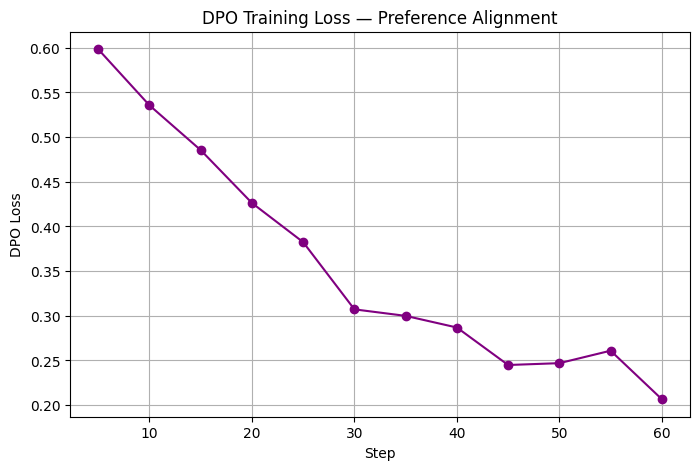

In [38]:
import matplotlib.pyplot as plt

log_history = dpo_trainer.state.log_history
losses = [x["loss"] for x in log_history if "loss" in x]
steps = [x["step"] for x in log_history if "loss" in x]

plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o", color="purple")
plt.xlabel("Step")
plt.ylabel("DPO Loss")
plt.title("DPO Training Loss — Preference Alignment")
plt.grid(True)
plt.savefig("dpo_loss_curve.png")
plt.show()

In [39]:
model.save_pretrained("outputs/dpo_adapter")
tokenizer.save_pretrained("outputs/dpo_adapter")

model.push_to_hub("kumarrohit1707/it-helpdesk-dpo-adapter", token=True)
tokenizer.push_to_hub("kumarrohit1707/it-helpdesk-dpo-adapter", token=True)

README.md:   0%|          | 0.00/536 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/kumarrohit1707/it-helpdesk-dpo-adapter


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [40]:
FastLanguageModel.for_inference(model)

def generate_dpo_answer(question, max_new_tokens=150):
    messages = [
        {"role": "system", "content": "You are an IT Helpdesk Assistant. Answer user IT support questions clearly and professionally."},
        {"role": "user", "content": question},
    ]
    inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
    outputs = model.generate(
        inputs, max_new_tokens=max_new_tokens, temperature=0.7, do_sample=True,
        repetition_penalty=1.2, eos_token_id=im_end_id, pad_token_id=tokenizer.pad_token_id,
    )
    return tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

test_questions = [
    "How can I fix a VPN connection that keeps disconnecting?",
    "My printer is not connecting to my MacBook, what should I do?",
    "I am facing a billing discrepancy on my recent invoice, how do I resolve it?",
    "What steps should I take if my SaaS platform is running slowly?",
    "How do I report a security breach affecting our systems?",
    "My Bluetooth headset won't pair with my laptop after a Windows update, help?",
    "How can I request a refund for a returned product?",
    "What should I do if my account has unauthorized login attempts?",
    "How do I set up VPN access for remote employees?",
    "My cloud storage sync keeps failing, how can I fix it?",
]

dpo_answers = []
for q in test_questions:
    ans = generate_dpo_answer(q)
    dpo_answers.append(ans)
    print(f"Q: {q}\nA: {ans}\n{'-'*80}")

Q: How can I fix a VPN connection that keeps disconnecting?
A: Dear customer, we apologize for the inconvenience caused by your disconnected VPN session. Here's how to troubleshoot this issue:
1. Ensure you have enabled "Always Connect" under Settings on your device.
2. Verify if multiple devices share one internet account; in such cases, try rebooting or updating all connected clients using the same application.
3. If none of these solutions work, please provide more details about your existing setup so our technical team can assist further. We're working diligently to resolve any connectivity issues promptly!
--------------------------------------------------------------------------------
Q: My printer is not connecting to my MacBook, what should I do?
A: We apologize for the inconvenience you're experiencing with your printer not being able to connect to your MacBook. Could you please provide us with more information about the issue such as whether it's a wireless or USB connection,